<a href="https://colab.research.google.com/github/Serge3leo/temp-cola/blob/main/valq/260325/e_cos_x_dx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import scipy
from math import *
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "retina"

In [2]:
a = 0.0065  # 0.0015
b = 0.0043  # 0.0010
c = 0.0039  # 0.0009
w = [1., 1., 1.]
if False:
    a = 0.0015
    b = 0.0010
    c = 0.0009

In [3]:
def fun(arg):
  e = np.asarray(arg[0])
  x = np.asarray(arg[1])
  dx = np.asarray(arg[2])
  return [w[0]*(a - e*np.cos(x + 0.*dx)),
          w[1]*(b - e*np.cos(x + dx)),
          w[2]*(c - e*np.cos(x + 2.*dx))]

In [4]:
x0 = np.array([(a + b + c)/3, pi/2 + 0., 0.])
res = scipy.optimize.least_squares(fun, x0)
res

     message: The maximum number of function evaluations is exceeded.
     success: False
      status: 0
         fun: [ 3.000e-04 -6.000e-04  3.000e-04]
           x: [ 8.415e-01  1.563e+00  1.545e-03]
        cost: 2.7000350875913817e-07
         jac: [[-7.368e-03  8.415e-01  0.000e+00]
               [-5.823e-03  8.415e-01  8.415e-01]
               [-4.278e-03  8.415e-01  1.683e+00]]
        grad: [-3.437e-10  4.629e-08  3.809e-08]
  optimality: 4.6294326022478496e-08
 active_mask: [ 0.000e+00  0.000e+00  0.000e+00]
        nfev: 300
        njev: 292

In [5]:
# e, x, dx
res.x

array([8.41522720e-01, 1.56342870e+00, 1.54483646e-03])

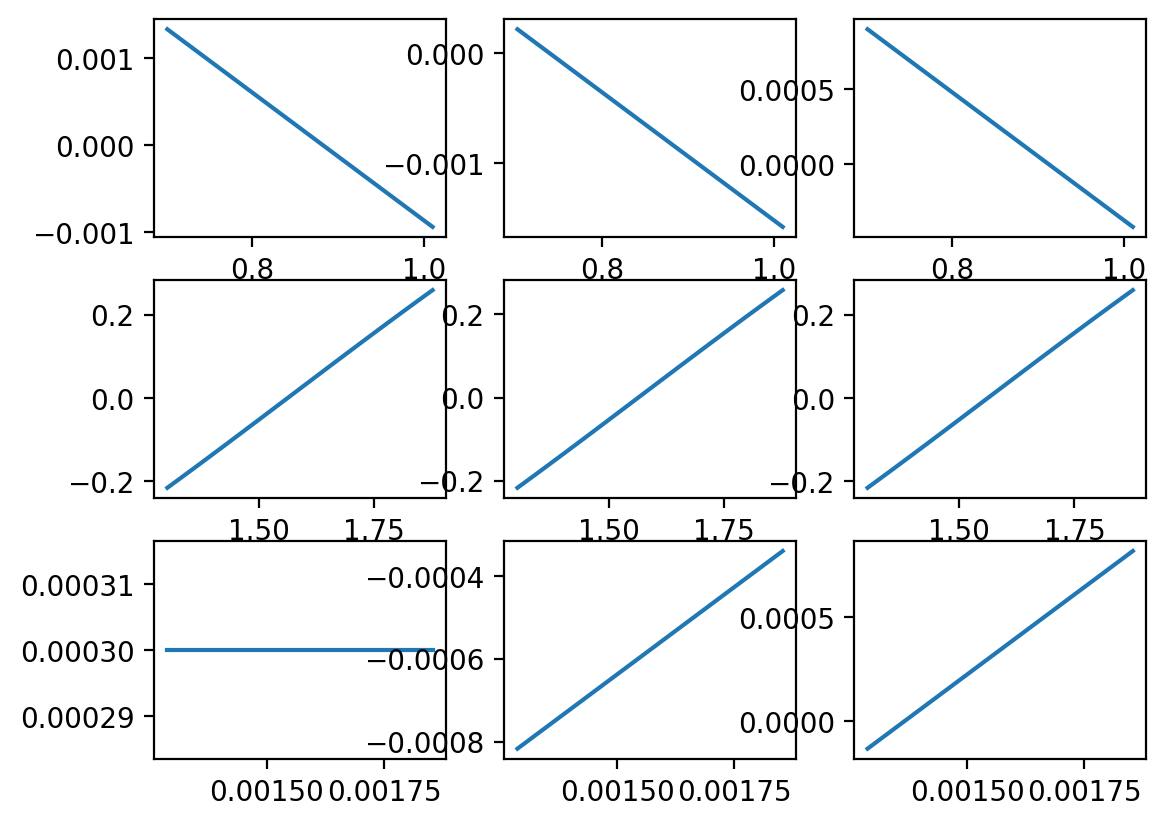

In [6]:
fig, ax = plt.subplots(3, 3)

for i in range(3):
  x = list(res.x)
  x[i] = np.linspace(res.x[i]/1.2, res.x[i]*1.2)
  f = fun(x)
  for j in range(3):
    ax[i][j].plot(x[i], f[j])

In [7]:
print(res.x, w)
for i in range(3):
  x1 = res.x
  w[i] = 1000.
  res1 = scipy.optimize.least_squares(fun, x1)
  print(res1.x, w)
  w[i] = 1.

[8.41522720e-01 1.56342870e+00 1.54483646e-03] [1.0, 1.0, 1.0]
[1.06340489e+00 1.56468385e+00 1.39177177e-03] [1000.0, 1.0, 1.0]
[1.07726572e+00 1.56559796e+00 1.20676478e-03] [1.0, 1000.0, 1.0]
[1.09114355e+00 1.56516918e+00 1.02645612e-03] [1.0, 1.0, 1000.0]
